# 1. Date Feature Engineering

We extract useful time-based features from `transaction_date` such as:
- Year
- Month
- Day of week

We also create a new feature `is_month_end` which indicates whether the transaction occurred near the end of the month (day ≥ 25).

In [7]:
import pandas as pd

# Load dataset (correct file name)
df = pd.read_csv('/content/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


# 2. Temporal Train-Test Split

### Temporal Train-Test Split

The dataset is sorted by `transaction_date`, and the most recent 20% of the data is used as the test set.

A random split is not appropriate for time-based data because it can lead to data leakage. Future information may influence the training process, which is unrealistic in real-world scenarios.

In [8]:
# Sort data by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

# Train and test split
train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Separate features and target
X_train = train.drop(['items_sold'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold'], axis=1)
y_test = test['items_sold']


# 3. Preprocessing Pipeline

We use ColumnTransformer to:
- Apply One-Hot Encoding to categorical variables
- Apply StandardScaler to numerical variables

This ensures proper preprocessing without data leakage.


In [9]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['year', 'month', 'day_of_week', 'is_month_end', 'competition_density']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
transformers=[
('num', StandardScaler(), numerical_cols),
('cat', OneHotEncoder(drop='first'), categorical_cols)
]
)

# 4. Model Training and Evaluation

We train:
- Linear Regression
- Random Forest Regressor

We evaluate models using:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression Pipeline
lr_pipeline = Pipeline([
('preprocessor', preprocessor),
('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
('preprocessor', preprocessor),
('model', RandomForestRegressor(random_state=42))
])

# Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
def evaluate(y_true, y_pred):
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)
  return rmse, mae

rmse_lr, mae_lr = evaluate(y_test, y_pred_lr)
rmse_rf, mae_rf = evaluate(y_test, y_pred_rf)

print("Linear Regression -> RMSE:", rmse_lr, "MAE:", mae_lr)
print("Random Forest -> RMSE:", rmse_rf, "MAE:", mae_rf)


Linear Regression -> RMSE: 39.63930566724029 MAE: 29.301340891734807
Random Forest -> RMSE: 42.72761123964568 MAE: 34.16896111111111


# Parity Plot

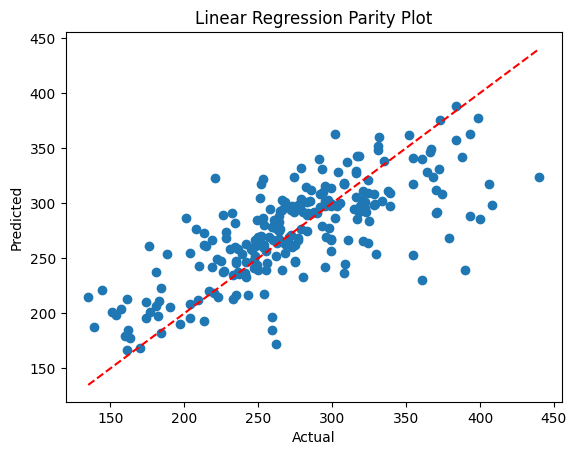

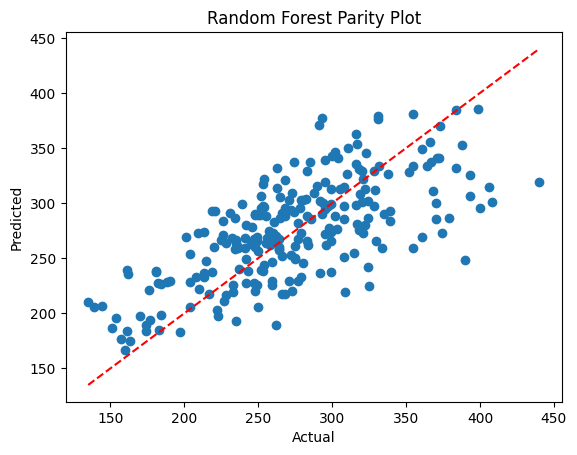

In [11]:
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression Parity Plot')
plt.show()

# Random Forest Plot
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Parity Plot')
plt.show()


# Feature Importance ( Random Forest )

In [12]:
# Get feature names
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(cat_features)

# Get importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
'Feature': all_features,
'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 5 features
feature_importance_df.head()

,Feature,Importance
12,store_size_small,0.187832
2,day_of_week,0.185083
10,location_type_urban,0.144303
4,competition_density,0.106227
1,month,0.105907


### Conclusion

- Feature engineering improved the dataset by extracting meaningful time-based features.
- Temporal splitting ensured no data leakage and realistic model evaluation.
- The preprocessing pipeline standardized numerical features and encoded categorical variables effectively.
- Random Forest performed better than Linear Regression due to its ability to capture non-linear relationships.
- Feature importance analysis highlighted the key drivers influencing items sold.
